In [35]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["font.sans-serif"] = "Arial"

%config InlineBackend.figure_format = 'retina'

sc.settings.set_figure_params(dpi=50, dpi_save=300, figsize=(4, 4))

### Load data

In [36]:
adata = sc.read_10x_mtx('data/filtered_gene_bc_matrices/', var_names='gene_symbols', cache=True)
# adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [37]:
obs = pd.read_csv('./data/filtered_gene_bc_matrices/barcodes.tsv', header=None, index_col=0, sep='\t')
var = pd.read_csv('./data/filtered_gene_bc_matrices/genes.tsv', header=None, index_col=1, sep='\t')
obs.index.name = ''
var.index.name = ''
var.columns = ['gene_ids']


from scipy.io import mmread
from scipy.sparse import csr_matrix
mtx = mmread('./data/filtered_gene_bc_matrices/matrix.mtx')
mtx = mtx.T
mtx = csr_matrix(mtx)
adata1 = sc.AnnData(mtx, obs=obs, var=var)

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [38]:
adata1.var_names_make_unique()

### QC

In [39]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

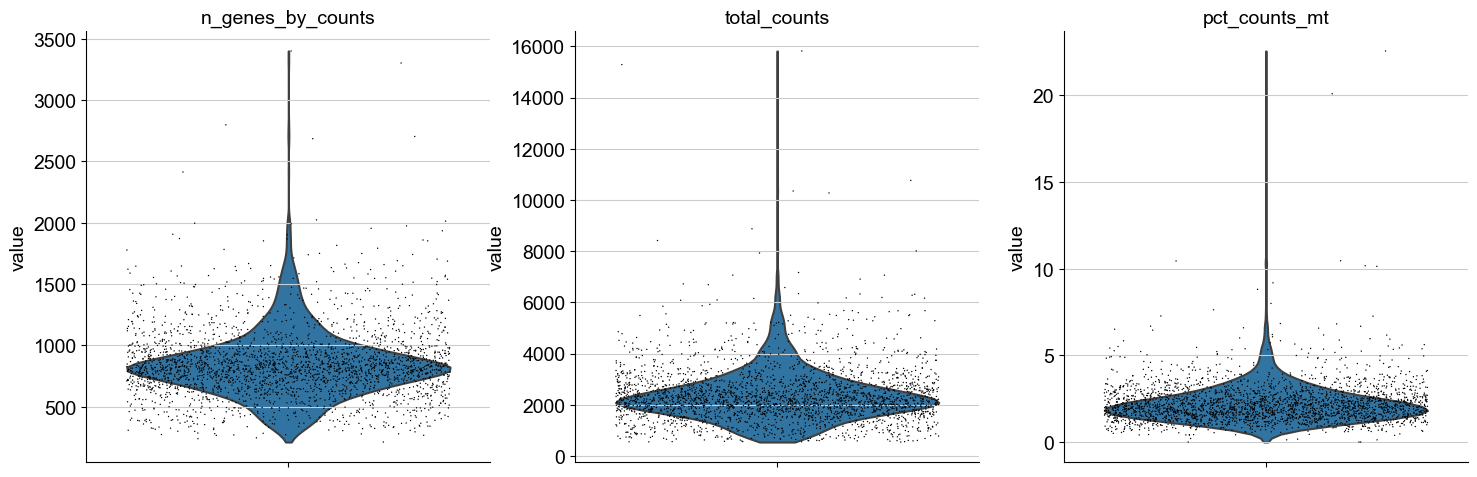

In [40]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

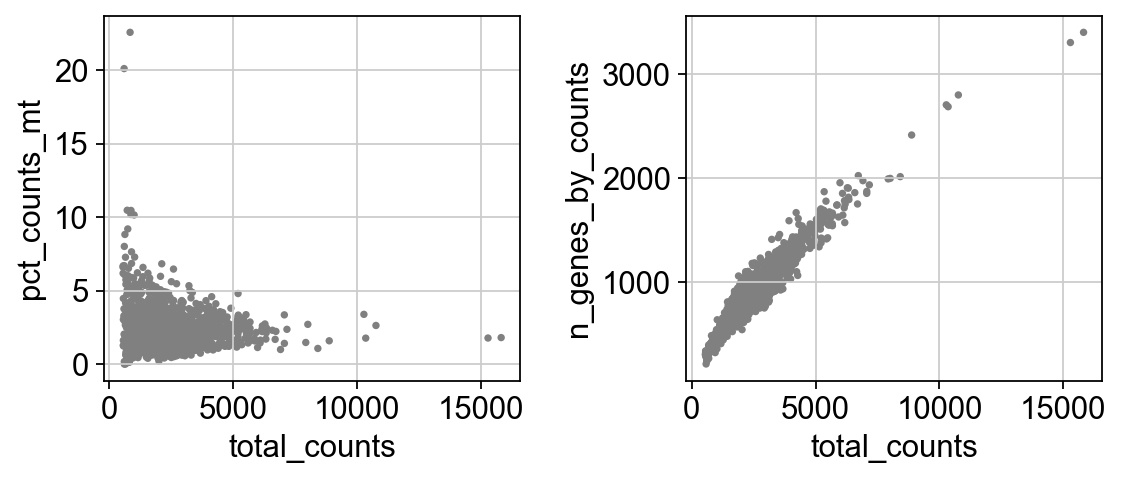

In [41]:
sc.settings.set_figure_params(dpi_save=300)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', ax=ax[0], show=False)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', ax=ax[1], show=False)
plt.subplots_adjust(wspace=.4)

In [42]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

### Normalization

In [43]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/home/liunianping/miniconda3/envs/ContentShare/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [44]:
adata

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'

### feature selection

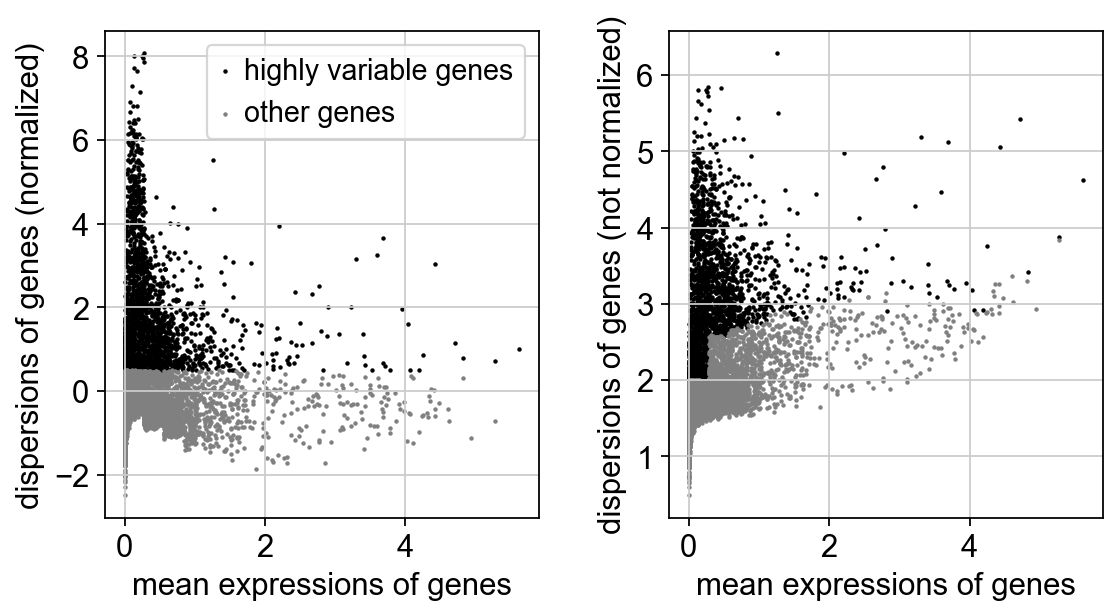

In [45]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

In [46]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]

In [47]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

### reduction

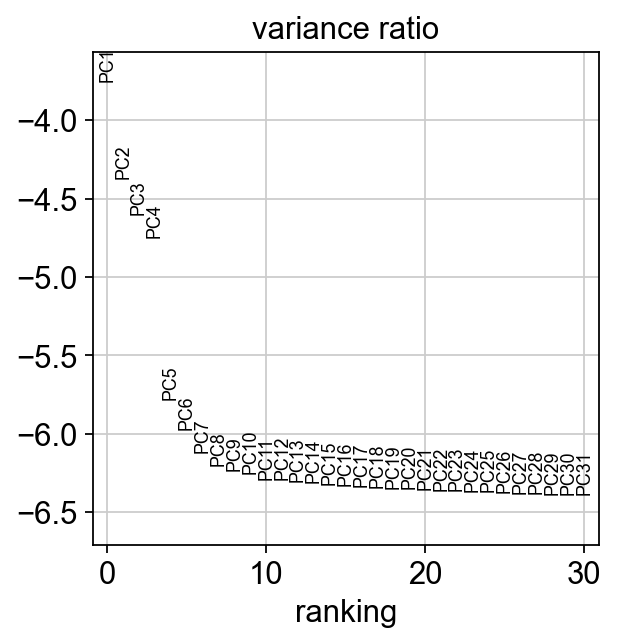

In [48]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

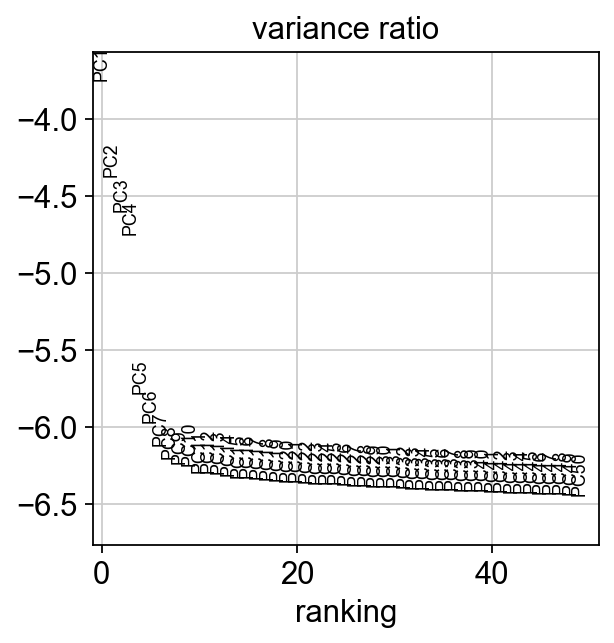

In [49]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [50]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

### Clustering

In [51]:
sc.tl.leiden(adata)

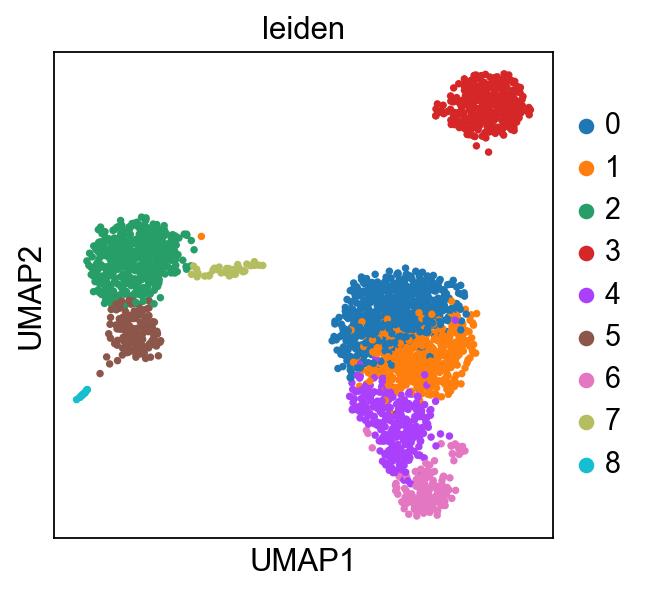

In [52]:
sc.pl.umap(adata, color='leiden')

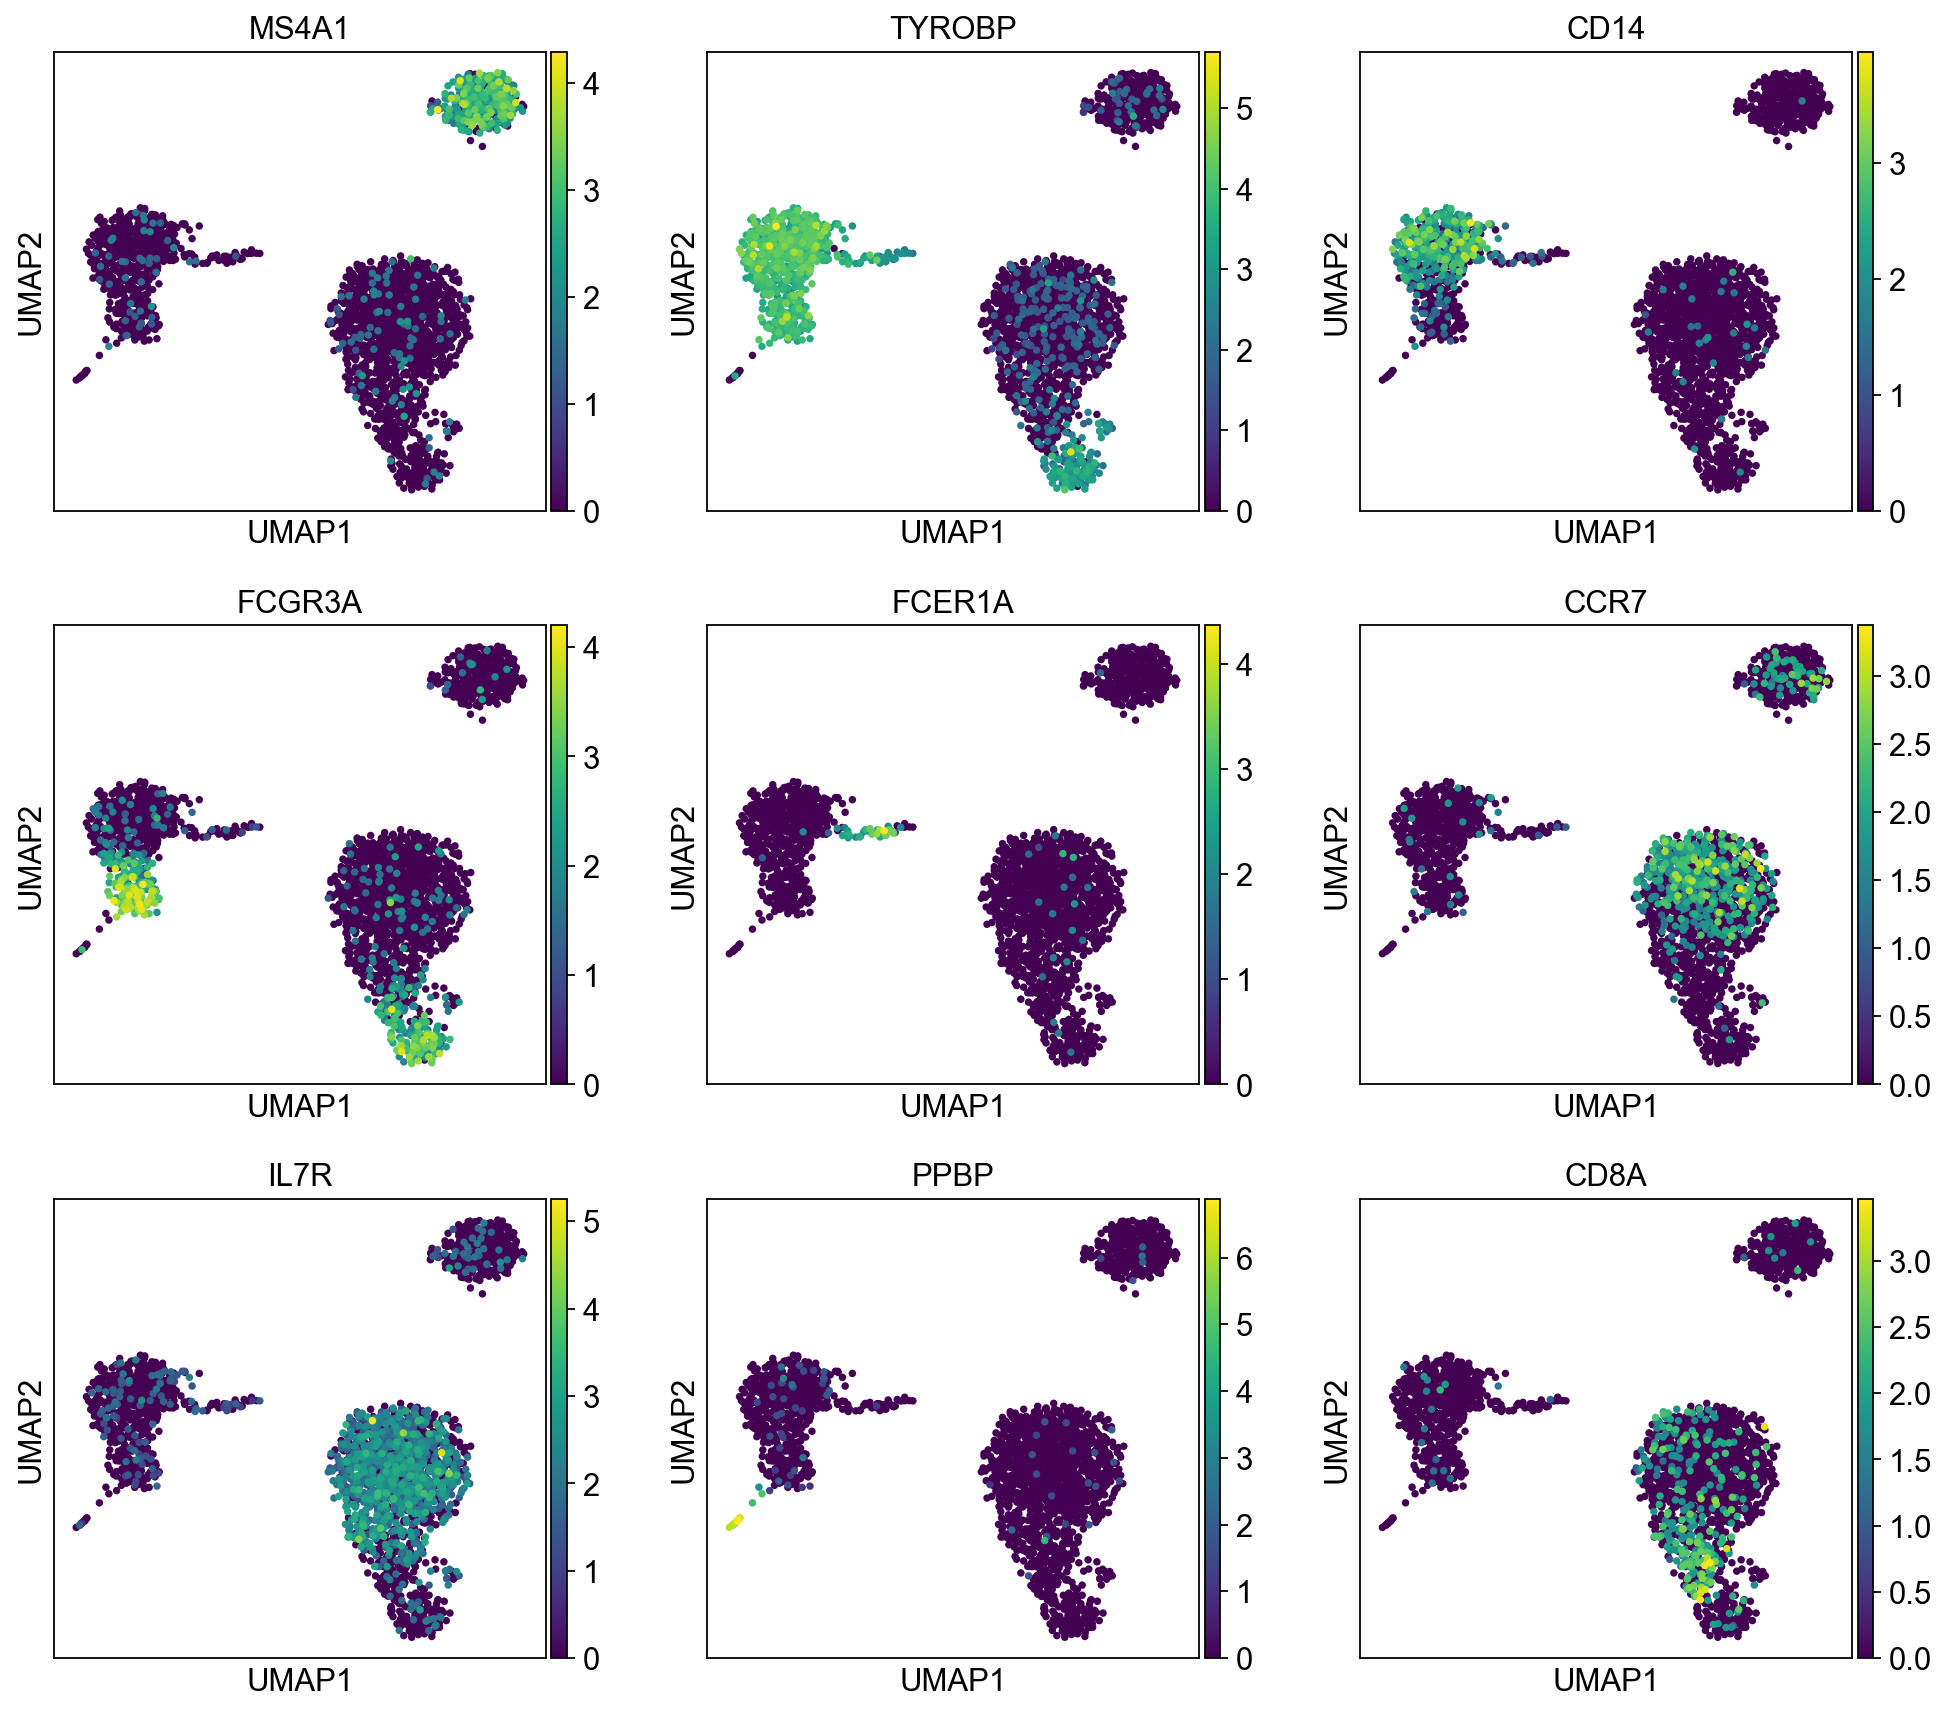

In [53]:
markers = ["MS4A1", "TYROBP", "CD14",'FCGR3A', "FCER1A", "CCR7", "IL7R", "PPBP", "CD8A"]
sc.pl.umap(adata, color=markers, ncols=3)

In [54]:
new_cluster_names = ['Naive CD4 T', 'Memory CD4', 'CD14 Monocytes','B', 'CD8 T', 'FCGR3A Monocytes','NK', 'DC', 'Platelet']
adata.rename_categories('leiden', new_cluster_names)

/home/liunianping/miniconda3/envs/ContentShare/lib/python3.9/site-packages/pandas/core/arrays/categorical.py:2631: FutureWarning: The `inplace` parameter in pandas.Categorical.rename_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  res = method(*args, **kwargs)


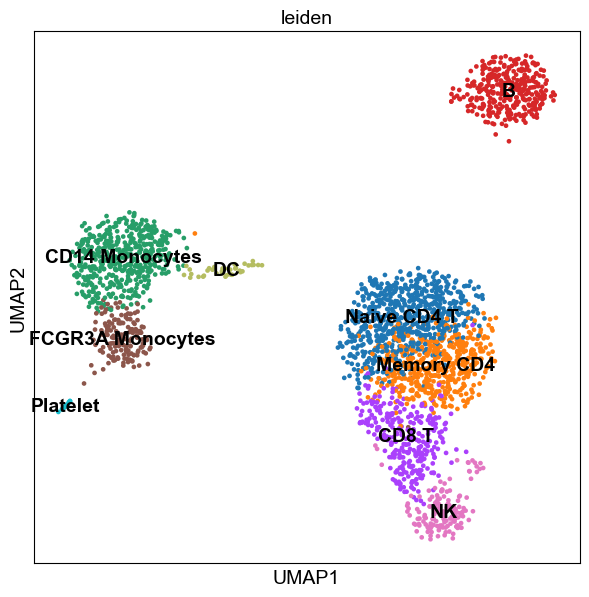

In [55]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, figsize=(7, 7))
sc.pl.umap(adata, color='leiden', legend_loc='on data')

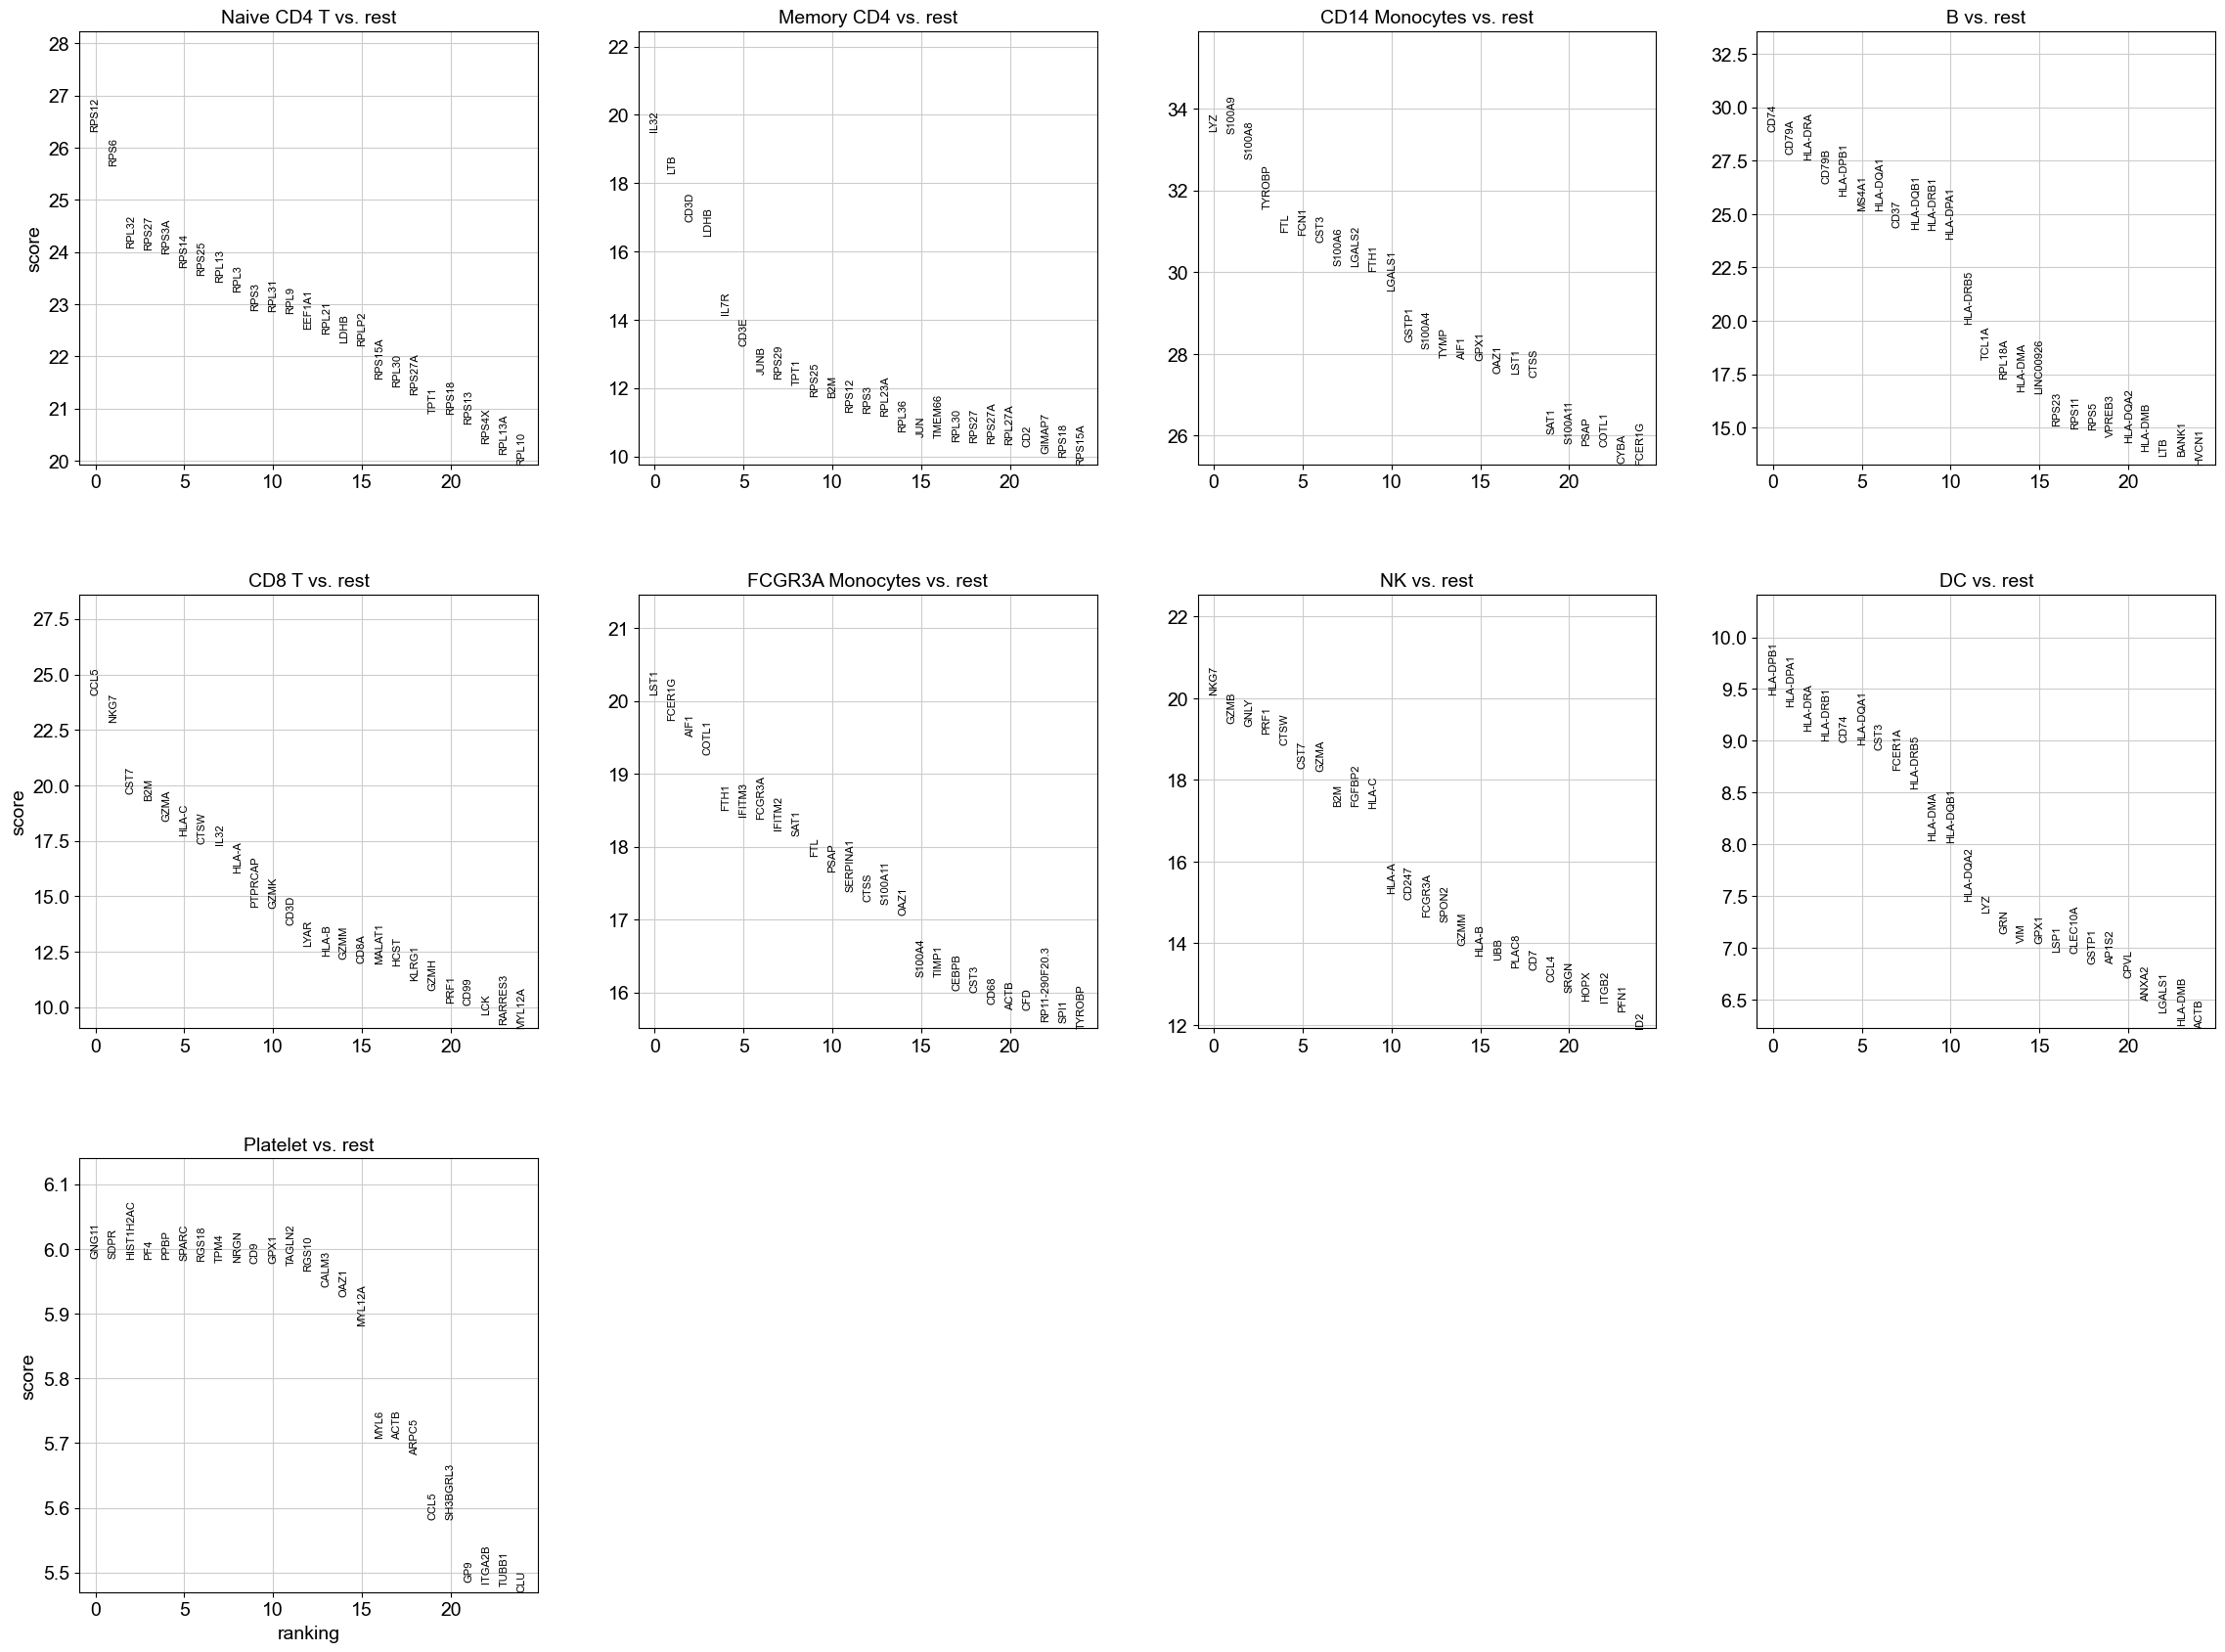

In [56]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

### Understand the data structure of Anndata

In [60]:
adata

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [82]:
adata_norm = adata.raw.to_adata()

In [83]:
adata_norm

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'